# Track C: Corrected quantum-gated branch — ResNet18, seven classes

**Retained architecture:** ResNet18 stem → layer1 → layer2 → layer3 (256 channels). A pooled copy goes through squeeze → 2-qubit circuit → 256-channel sigmoid gate. The gate multiplies the layer3 feature map; layer4 and global pooling then produce **512 features for the seven-class head**.

There is **no two-value bottleneck on the final classifier path** in this model, so no late-fusion concatenation was added.

**Changes matching the corrected Track B:** no weighted sampler or class-weighted loss; separate transform / Dataset / split-and-loader cells; seeded **70% training / 15% validation / 15% test** image-level split. Keep seed 42, batch size 32, maximum 20 epochs, learning rate 5e-5, patience 5, two qubits and two circuit layers. Keep pretrained ResNet18, full-model training, ImageNet normalization, and no augmentation.

**Comparison:** the data and split code matches the corrected Track B notebook. With identical CSV rows, images, and PyTorch behavior, assignments match; verify the saved split manifests rather than assuming a shared seed alone guarantees it.

**Limitation:** the reference uses an image-level split, not a lesion-disjoint split. Different photos of the same lesion can cross partitions; overlap counts are printed. The test subset is withheld from early stopping but is not necessarily independent at lesion level. Compare only experiments with matching protocols, not directly against the old 80/20 run.

Best weights, full-precision validation/test metrics, predictions, plots, split manifest, and configuration are saved in a unique run directory. Grad-CAM and gate visualizations use validation samples only. These visualizations are descriptive, not proof of quantum benefit or clinical validity.

Run on Kaggle with GPU and Internet enabled. Start fresh training for the revised experiment. The original notebook is unchanged; this file has no executed training results.

In [1]:
%pip install -q pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 76.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 51.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 71.8 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import copy
import glob
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)

import pennylane as qml

# Retained training settings; revised split and architecture must match other tracks.
CSV_PATH = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/HAM10000_metadata.csv"
IMG_DIR  = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/Skin Cancer/Skin Cancer"

N_QUBITS   = 2       # retained qubit count
N_QLAYERS  = 2        # retained circuit depth
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
SEED = 42

# All 7 HAM10000 diagnostic classes -- fixed order, must be identical across all three notebooks
CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
NUM_CLASSES = len(CLASS_NAMES)
LABEL_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def round3(d):
    """Round every numeric value in a dict to 3 decimal places for reporting."""
    out = {}
    for k, v in d.items():
        if isinstance(v, (int, float, np.floating)) and not (isinstance(v, float) and np.isnan(v)):
            out[k] = round(float(v), 3)
        else:
            out[k] = v
    return out
from pathlib import Path
from datetime import datetime, timezone
import json
import uuid

FULL_EPOCHS = 20
LR = 5e-5
PATIENCE = 5
RUN_DIR = Path("/kaggle/working/checkpoints") / (
    "quantum_gated_fixed_" + datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
    + "_" + uuid.uuid4().hex[:8]
)
RUN_DIR.mkdir(parents=True, exist_ok=False)
print("Output directory:", RUN_DIR)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CPU runtime; full training may be slow.")

Using device: cuda
Output directory: /kaggle/working/checkpoints/quantum_gated_fixed_20260902_124554_064503dd
GPU: Tesla T4


## 1. Transform (reference-style separate cell)
Keep ImageNet normalization for the pretrained ResNet; add zoom augmentation only.

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.7, 1.0)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## 2. Dataset definition
Resolve image IDs recursively; fail on missing/ambiguous paths rather than silently changing the dataset.

In [4]:
class SkinCancerDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file).reset_index(drop=True)
        required = {"image_id", "dx", "lesion_id"}
        if not required.issubset(self.df.columns):
            raise ValueError(f"Metadata missing columns: {required - set(self.df.columns)}")
        if self.df[list(required)].isna().any().any():
            raise ValueError("Missing image_id, dx, or lesion_id.")
        if self.df["image_id"].duplicated().any():
            raise ValueError("Duplicate image_id rows in metadata.")
        if not self.df["dx"].isin(CLASS_NAMES).all():
            raise ValueError("Unexpected diagnostic classes.")
        self.classes = list(CLASS_NAMES)
        self.class_to_idx = dict(LABEL_TO_IDX)
        self.transform = transform
        lookup = {}
        for p in sorted(Path(img_dir).rglob("*")):
            if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
                if p.stem in lookup:
                    raise ValueError(f"Ambiguous image ID: {p.stem}")
                lookup[p.stem] = str(p)
        self.df["filepath"] = self.df["image_id"].map(lookup)
        missing = self.df.loc[self.df["filepath"].isna(), "image_id"]
        if len(missing):
            raise FileNotFoundError(f"{len(missing)} images missing; examples: {missing.head().tolist()}")
        self.df["label"] = self.df["dx"].map(self.class_to_idx).astype(int)
        print(f"Total images: {len(self.df)}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["filepath"]) as image:
            image = image.convert("RGB")
            if self.transform is not None:
                image = self.transform(image)
        return image, int(row["label"])

## 3. Full dataset → train / validation / test → loaders
Reference proportions and random_split structure, with a dedicated seed generator. No oversampling or loss weighting. Test data is not used for early stopping.

In [5]:
full_dataset = SkinCancerDataset(CSV_PATH, IMG_DIR, transform)
train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)
subsets = {"train": train_dataset, "validation": val_dataset, "test": test_dataset}
manifest_parts = []
index_sets = [set(subset.indices) for subset in subsets.values()]
assert not (index_sets[0] & index_sets[1] or index_sets[0] & index_sets[2] or index_sets[1] & index_sets[2])
assert len(set.union(*index_sets)) == len(full_dataset)
for split, subset in subsets.items():
    rows = full_dataset.df.iloc[subset.indices].copy()
    rows["split"] = split
    manifest_parts.append(rows)
    counts = rows["dx"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    print(f"\n{split}: {len(subset)} images\n{counts}")
    if (counts == 0).any():
        raise ValueError(f"{split} lacks a class; agree on a revised split before training.")
manifest = pd.concat(manifest_parts, ignore_index=True)
manifest[["image_id", "lesion_id", "dx", "label", "split"]].to_csv(
    RUN_DIR / "split_manifest.csv", index=False
)
for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    overlap = set(manifest.loc[manifest["split"] == a, "lesion_id"]) & set(
        manifest.loc[manifest["split"] == b, "lesion_id"])
    print(f"Shared lesion IDs ({a}/{b}): {len(overlap)}")
print("Image-level split: any lesion overlap limits independence of reported scores.")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
)
print("Batches:", len(train_loader), len(val_loader), len(test_loader))

Total images: 10015

train: 7010 images
dx
akiec     215
bcc       352
bkl       802
df         81
mel       783
nv       4670
vasc      107
Name: count, dtype: int64

validation: 1502 images
dx
akiec      56
bcc        83
bkl       139
df         14
mel       167
nv       1027
vasc       16
Name: count, dtype: int64

test: 1503 images
dx
akiec      56
bcc        79
bkl       158
df         20
mel       163
nv       1008
vasc       19
Name: count, dtype: int64
Shared lesion IDs (train/validation): 477
Shared lesion IDs (train/test): 502
Shared lesion IDs (validation/test): 129
Image-level split: any lesion overlap limits independence of reported scores.
Batches: 220 47 47


## 4. Quantum layer — retained 2-qubit circuit

In [6]:
q_device = qml.device("default.qubit", wires=N_QUBITS)

def _circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

qnode = qml.QNode(_circuit, q_device, interface="torch", diff_method="backprop")
weight_shapes = {"weights": (N_QLAYERS, N_QUBITS)}

def make_quantum_layer():
    return qml.qnn.TorchLayer(qnode, weight_shapes)

## 5. Quantum-gated ResNet18
The quantum branch gates 256 layer3 channels; the classifier retains all 512 pooled layer4 features.

In [7]:
class QuantumGatedResNet(nn.Module):
    def __init__(self, pretrained=True, freeze_stem=False):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)

        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3   # quantum gate taps here -> 256 channels
        self.layer4 = resnet.layer4
        self.avgpool = resnet.avgpool

        if freeze_stem:
            for p in self.stem.parameters():
                p.requires_grad = False

        GATE_CHANNELS = 256
        self.squeeze = nn.Sequential(
            nn.Linear(GATE_CHANNELS, 32), nn.ReLU(), nn.Linear(32, N_QUBITS), nn.Tanh()
        )
        self.quantum = make_quantum_layer()
        self.excite = nn.Sequential(nn.Linear(N_QUBITS, GATE_CHANNELS), nn.Sigmoid())

        self.head = nn.Linear(512, NUM_CLASSES)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)                                            # (B, 256, H, W)

        pooled = x.mean(dim=[2, 3])
        q_in = self.squeeze(pooled) * np.pi
        q_out = self.quantum(q_in.to(device="cpu", dtype=torch.float32))
        q_out = q_out.to(device=x.device, dtype=x.dtype)
        gate = self.excite(q_out).unsqueeze(-1).unsqueeze(-1)  # (B, 256, 1, 1)

        x = x * gate
        x = self.layer4(x)
        x = self.avgpool(x).flatten(1)
        return self.head(x)

## 6. Architecture checks
The smoke test below verifies seven logits and nonzero, finite gradients through the visual and quantum-gating branches.

In [8]:
assert callable(QuantumGatedResNet)
print("Final head: 512 visual features -> 7 classes; quantum branch gates layer3.")

Final head: 512 visual features -> 7 classes; quantum branch gates layer3.


## 7. Forward/backward smoke check
Uses a disposable unpretrained model and synthetic inputs. Checks both branches receive finite, nonzero gradients; this does not measure training quality.

In [9]:
with torch.random.fork_rng(devices=list(range(torch.cuda.device_count()))):
    torch.manual_seed(SEED)
    smoke_model = QuantumGatedResNet(pretrained=False).to(DEVICE).eval()
    smoke_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    smoke_y = torch.tensor([0, 1], device=DEVICE)
    smoke_logits = smoke_model(smoke_x)
    assert smoke_logits.shape == (2, NUM_CLASSES)
    assert smoke_model.head.in_features == 512
    smoke_loss = nn.CrossEntropyLoss()(smoke_logits, smoke_y)
    assert torch.isfinite(smoke_loss)
    smoke_loss.backward()
    for name, module in [("stem", smoke_model.stem),
                         ("layer3", smoke_model.layer3),
                         ("layer4", smoke_model.layer4),
                         ("squeeze", smoke_model.squeeze),
                         ("quantum", smoke_model.quantum),
                         ("excite", smoke_model.excite),
                         ("head", smoke_model.head)]:
        grads = [p.grad for p in module.parameters() if p.requires_grad]
        assert grads and all(g is not None and torch.isfinite(g).all() for g in grads), name
        assert sum(g.abs().sum().item() for g in grads) > 0, name
    print("PASS: output shape, finite loss, and gradients through visual and quantum-gating branches.")
    del smoke_model, smoke_x, smoke_y, smoke_logits, smoke_loss, grads, module
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

PASS: output shape, finite loss, and gradients through visual and quantum-gating branches.


## 8. Training and evaluation utilities — unweighted cross-entropy

In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy().tolist())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.array(all_labels)
    preds = all_probs.argmax(axis=1)

    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, preds),
        "precision_macro": precision_score(all_labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(all_labels, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(all_labels, preds, average="macro", zero_division=0),
        "auc_macro_ovr": auc,
    }
    return metrics, all_probs, all_labels

def run_training(model, train_loader, val_loader, epochs, lr,
                  early_stopping=True, patience=5, monitor="f1_macro", min_delta=1e-4, verbose=True, checkpoint_path=None):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f1": []}
    best_score, best_state, best_epoch, epochs_no_improve = -float("inf"), None, 0, 0

    for epoch in range(epochs):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_auc"].append(val_metrics["auc_macro_ovr"])
        history["val_f1"].append(val_metrics["f1_macro"])

        current = val_metrics[monitor]
        improved = current > best_score + min_delta
        flag = ""
        if improved:
            best_score, best_state, best_epoch, epochs_no_improve = current, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, epoch + 1, 0
            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)
            flag = "  <- best so far"
        else:
            epochs_no_improve += 1

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} | train_loss={tr_loss:.3f} | val_loss={val_metrics['loss']:.3f} "
                  f"| val_acc={val_metrics['accuracy']:.3f} | val_auc={val_metrics['auc_macro_ovr']:.3f} "
                  f"| val_f1={val_metrics['f1_macro']:.3f} | {time.time()-t0:.1f}s{flag}")

        if early_stopping and epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping after epoch {epoch+1} (no improvement in {monitor} for {patience} epochs). "
                      f"Restoring weights from epoch {best_epoch}.")
            break

    if early_stopping and best_state is not None:
        model.load_state_dict(best_state)
    return model, history

## 9. Train the main model
20-epoch maximum; select best validation macro-F1, stop after five non-improving epochs. Best weights are saved as soon as improvement occurs (weights-only, not an optimizer-resume checkpoint).

In [11]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

BEST_PATH = RUN_DIR / "quantum_gated_resnet18_2q.pt"
print("Training with ordinary shuffled batches and unweighted CrossEntropyLoss.")
gated_model = QuantumGatedResNet(pretrained=True, freeze_stem=False)
gated_model, gated_history = run_training(
    gated_model, train_loader, val_loader, FULL_EPOCHS, LR,
    early_stopping=True, patience=PATIENCE, monitor="f1_macro",
    checkpoint_path=BEST_PATH,
)
history_df = pd.DataFrame(gated_history)
history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
history_df.to_csv(RUN_DIR / "training_history.csv", index=False)

Training with ordinary shuffled batches and unweighted CrossEntropyLoss.
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


Epoch 1/20 | train_loss=0.940 | val_loss=0.574 | val_acc=0.810 | val_auc=0.949 | val_f1=0.549 | 85.6s  <- best so far
Epoch 2/20 | train_loss=0.472 | val_loss=0.444 | val_acc=0.826 | val_auc=0.965 | val_f1=0.579 | 50.3s  <- best so far
Epoch 3/20 | train_loss=0.353 | val_loss=0.419 | val_acc=0.840 | val_auc=0.972 | val_f1=0.643 | 50.3s  <- best so far
Epoch 4/20 | train_loss=0.249 | val_loss=0.409 | val_acc=0.846 | val_auc=0.973 | val_f1=0.675 | 51.2s  <- best so far
Epoch 5/20 | train_loss=0.196 | val_loss=0.450 | val_acc=0.846 | val_auc=0.971 | val_f1=0.676 | 51.7s  <- best so far
Epoch 6/20 | train_loss=0.140 | val_loss=0.443 | val_acc=0.857 | val_auc=0.970 | val_f1=0.683 | 50.9s  <- best so far
Epoch 7/20 | train_loss=0.108 | val_loss=0.432 | val_acc=0.866 | val_auc=0.971 | val_f1=0.731 | 52.0s  <- best so far
Epoch 8/20 | train_loss=0.086 | val_loss=0.475 | val_acc=0.858 | val_auc=0.972 | val_f1=0.713 | 50.7s
Epoch 9/20 | train_loss=0.068 | val_loss=0.496 | val_acc=0.852 | val_auc

## 10. Training curves

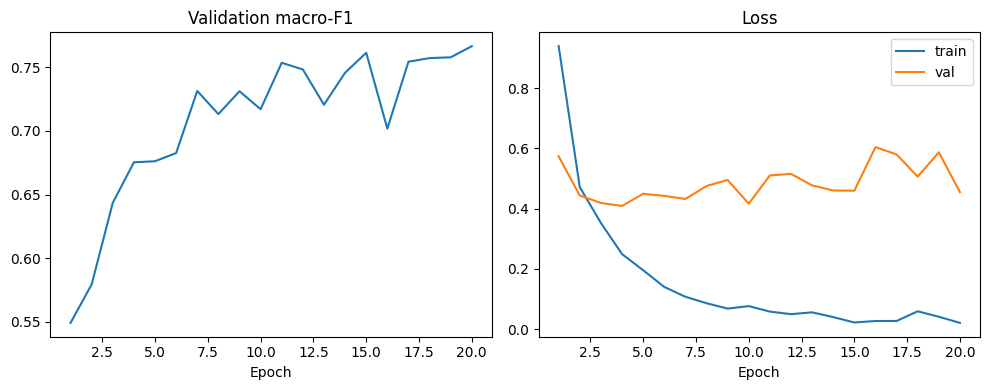

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
epochs_axis = range(1, len(gated_history["val_f1"]) + 1)
axes[0].plot(epochs_axis, gated_history["val_f1"]); axes[0].set_title("Validation macro-F1"); axes[0].set_xlabel("Epoch")
axes[1].plot(epochs_axis, gated_history["train_loss"], label="train"); axes[1].plot(epochs_axis, gated_history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "training_curves.png", dpi=160)
plt.show()

## 11. Final validation and held-out image-level test evaluation
The main model has restored the validation-selected weights. Do not tune on these test results. Lesion overlap warning still applies.


=== VALIDATION metrics ===
{'loss': 0.484, 'accuracy': 0.874, 'precision_macro': 0.805, 'recall_macro': 0.746, 'f1_macro': 0.771, 'auc_macro_ovr': 0.972}
              precision    recall  f1-score   support

       akiec      0.714     0.625     0.667        56
         bcc      0.835     0.795     0.815        83
         bkl      0.770     0.698     0.732       139
          df      0.800     0.571     0.667        14
         mel      0.641     0.707     0.672       167
          nv      0.938     0.949     0.944      1027
        vasc      0.933     0.875     0.903        16

    accuracy                          0.874      1502
   macro avg      0.805     0.746     0.771      1502
weighted avg      0.874     0.874     0.874      1502



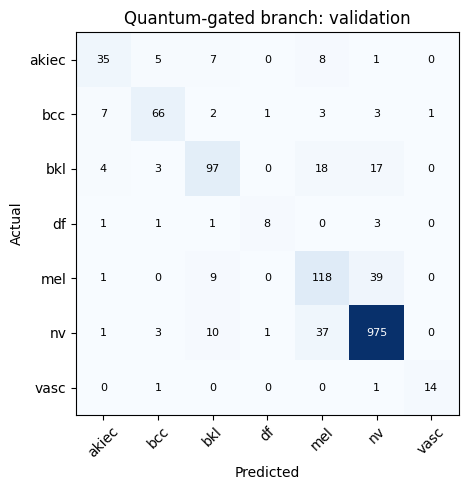


=== TEST metrics ===
{'loss': 0.497, 'accuracy': 0.866, 'precision_macro': 0.806, 'recall_macro': 0.759, 'f1_macro': 0.774, 'auc_macro_ovr': 0.975}
              precision    recall  f1-score   support

       akiec      0.744     0.518     0.611        56
         bcc      0.812     0.709     0.757        79
         bkl      0.868     0.709     0.780       158
          df      0.875     0.700     0.778        20
         mel      0.588     0.736     0.654       163
          nv      0.930     0.943     0.936      1008
        vasc      0.826     1.000     0.905        19

    accuracy                          0.866      1503
   macro avg      0.806     0.759     0.774      1503
weighted avg      0.871     0.866     0.865      1503



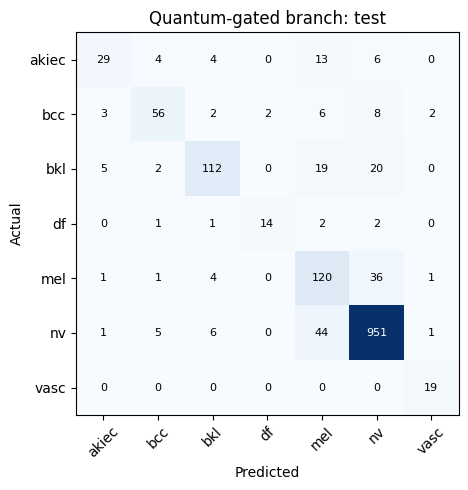

In [13]:
criterion = nn.CrossEntropyLoss()
metrics_rows = []
for split, loader, subset in [
    ("validation", val_loader, val_dataset),
    ("test", test_loader, test_dataset),
]:
    metrics, probs, labels = evaluate(gated_model, loader, criterion)
    preds = probs.argmax(axis=1)
    metrics_rows.append({"model": "Quantum-gated branch", "split": split, **metrics})
    print(f"\n=== {split.upper()} metrics ===")
    print(round3(metrics))
    print(classification_report(
        labels, preds, labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES,
        digits=3, zero_division=0,
    ))
    report = classification_report(
        labels, preds, labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES,
        output_dict=True, zero_division=0,
    )
    pd.DataFrame(report).transpose().to_csv(RUN_DIR / f"{split}_classification_report.csv")
    prediction_df = full_dataset.df.iloc[subset.indices][["image_id", "lesion_id"]].reset_index(drop=True)
    prediction_df["true_label"] = labels
    prediction_df["predicted_label"] = preds
    for i, cls in enumerate(CLASS_NAMES):
        prediction_df[f"prob_{cls}"] = probs[:, i]
    prediction_df.to_csv(RUN_DIR / f"{split}_predictions.csv", index=False)
    cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45)
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
    ax.set(xlabel="Predicted", ylabel="Actual", title=f"Quantum-gated branch: {split}")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.savefig(RUN_DIR / f"{split}_confusion_matrix.png", dpi=160)
    plt.show()
pd.DataFrame(metrics_rows).to_csv(RUN_DIR / "quantum_gated_branch_metrics.csv", index=False)

## 12. Export deployment artifacts and verify backend inference\n\nThe deployment ZIP contains only model weights and the reconstruction manifest.\n

In [ ]:
# Export the restored best-validation model and backend inference manifest.
import shutil
import torchvision
from pathlib import Path
from IPython.display import FileLink, HTML, display

DEPLOY_DIR = Path("/kaggle/working/skin_cancer_backend_model")
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = DEPLOY_DIR / "skin_cancer_model.pth"
CONFIG_PATH = DEPLOY_DIR / "skin_cancer_config.json"
ZIP_PATH = Path("/kaggle/working/skin_cancer_backend_model.zip")

# gated_model was restored to the validation-selected best state by run_training.
torch.save(
    {key: value.detach().cpu() for key, value in gated_model.state_dict().items()},
    MODEL_PATH,
)

# The attributes are available after a fresh Run All. This fallback also supports
# sessions where training completed before this deployment cell was added.
selected_best_epoch = getattr(gated_model, "best_epoch", None)
selected_best_f1 = getattr(gated_model, "best_validation_f1", None)
if selected_best_epoch is None or selected_best_f1 is None:
    selected_best_epoch = 0
    selected_best_f1 = -float("inf")
    for epoch, validation_f1 in enumerate(gated_history["val_f1"], start=1):
        if validation_f1 > selected_best_f1 + 1e-4:
            selected_best_epoch = epoch
            selected_best_f1 = validation_f1

class_descriptions = {
    "akiec": "Actinic keratoses / intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions",
}
config = {
    "model_name": "QuantumGatedResNet",
    "architecture": "ResNet18 layer3 -> quantum-controlled 256-channel gate -> layer4 -> avgpool(512) -> Linear(512,7)",
    "backbone": "ResNet18",
    "class_names": CLASS_NAMES,
    "class_to_index": LABEL_TO_IDX,
    "class_descriptions": class_descriptions,
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "input_channels": 3,
    "rgb_required": True,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "inference_transform_order": [
        "PIL.Image.convert('RGB')",
        "Resize((IMG_SIZE, IMG_SIZE))",
        "ToTensor()",
        "Normalize(IMAGENET_MEAN, IMAGENET_STD)",
    ],
    "inference_augmentation": "none; do not use random training augmentation",
    "training_augmentation_documentation": "RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.7, 1.0)) in the existing training transform",
    "n_qubits": N_QUBITS,
    "n_quantum_layers": N_QLAYERS,
    "pennylane_device": "default.qubit",
    "quantum_embedding": "qml.AngleEmbedding",
    "quantum_circuit_type": "qml.BasicEntanglerLayers with PauliZ expectation values",
    "quantum_gate_location": "ResNet18 layer3 output",
    "quantum_gate_channels": 256,
    "final_visual_representation": 512,
    "seed": SEED,
    "split": "seeded image-level random_split 70/15/15",
    "output_type": "logits",
    "probability_operation": "softmax",
    "best_epoch": selected_best_epoch,
    "best_validation_macro_f1": selected_best_f1,
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "pennylane_version": qml.__version__,
}
CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding="utf-8")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()
shutil.make_archive(
    str(ZIP_PATH.with_suffix("")),
    "zip",
    root_dir=DEPLOY_DIR.parent,
    base_dir=DEPLOY_DIR.name,
)

print("Deployment files:")
for path in (MODEL_PATH, CONFIG_PATH, ZIP_PATH):
    print(path.resolve())
print(f"Download this ZIP from Kaggle: {ZIP_PATH.resolve()}")
zip_link = os.path.relpath(ZIP_PATH, Path.cwd())
display(FileLink(zip_link, result_html_prefix="Kaggle download link: "))
display(HTML(
    f'<a href="{zip_link}" download="{ZIP_PATH.name}">'
    f'Download {ZIP_PATH.name}</a>'
))

# Fresh-load backend simulation using deterministic inference preprocessing only.
reloaded_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
reloaded_model = QuantumGatedResNet(pretrained=False, freeze_stem=False)
reloaded_model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
reloaded_model.eval()

inference_transform = T.Compose([
    T.Resize((reloaded_config["img_size"], reloaded_config["img_size"])),
    T.ToTensor(),
    T.Normalize(reloaded_config["imagenet_mean"], reloaded_config["imagenet_std"]),
])
raw_image_path = full_dataset.df.iloc[0]["filepath"]
with Image.open(raw_image_path) as raw_image:
    image_tensor_cpu = inference_transform(raw_image.convert("RGB")).unsqueeze(0)

gated_model.eval()
with torch.no_grad():
    original_logits = gated_model(image_tensor_cpu.to(DEVICE)).cpu()
    reloaded_logits = reloaded_model(image_tensor_cpu)
    probabilities = torch.softmax(reloaded_logits, dim=1)

# CPU reload versus the original runtime may differ by a few float32 ULPs.
np.testing.assert_allclose(
    original_logits.numpy(), reloaded_logits.numpy(), rtol=1e-4, atol=1e-5
)
np.testing.assert_allclose(probabilities.sum(dim=1).numpy(), np.ones(1), atol=1e-6)
predicted_class = int(probabilities.argmax(dim=1).item())
print("Smoke test passed: reloaded CPU model matches the restored best model.")
for class_code, probability in zip(reloaded_config["class_names"], probabilities[0].tolist()):
    print(f"{class_code}: {probability}")
print("Predicted class:", reloaded_config["class_names"][predicted_class])
print("Description:", reloaded_config["class_descriptions"][reloaded_config["class_names"][predicted_class]])


## 13. Explainability: Grad-CAM and quantum-controlled gate values

Uses a fixed sample of validation images, never test images. Grad-CAM is computed for the predicted logit. Hooks are removed after use so rerunning the cell does not accumulate hooks. Main training results are saved before this section.

Gate values near zero attenuate a channel; values near one preserve it. The learned classical excitation layer converts two expectation values into 256 gate values. A histogram by itself does not establish useful or quantum-specific selectivity. The expectation values are learned circuit outputs, **not validated medical risk factors**.

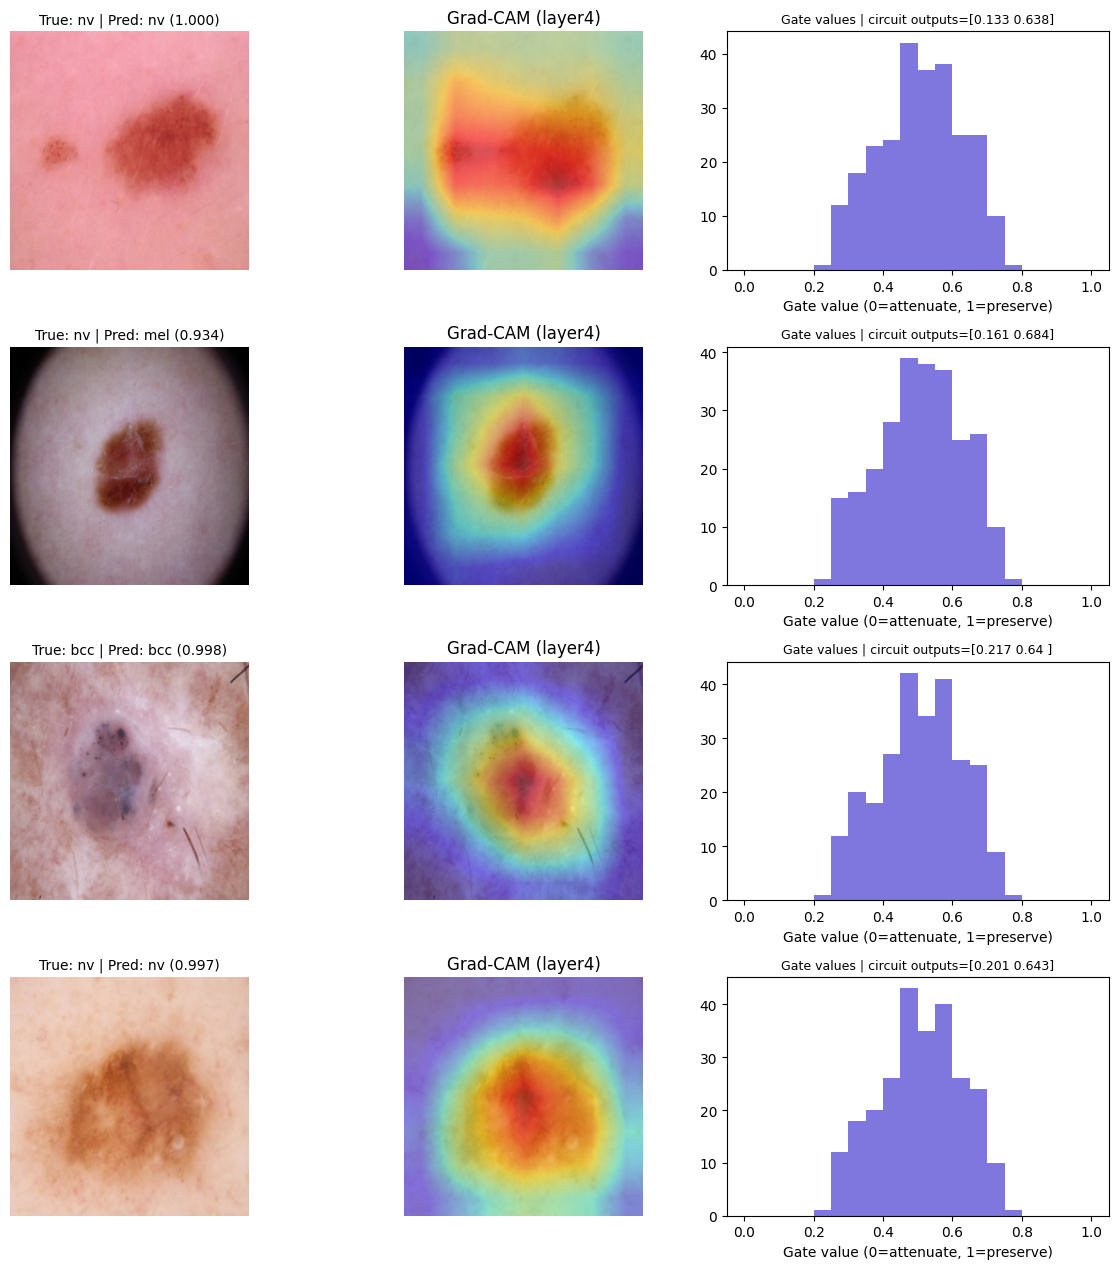

Updated results archive, including explainability:


/kaggle/working/checkpoints/quantum_gated_fixed_20260902_124554_064503dd.zip

In [15]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()
        # Tensor hook avoids module backward-hook/in-place interactions.
        if output.requires_grad:
            output.register_hook(self._save_gradient)

    def _save_gradient(self, gradient):
        self.gradients = gradient.detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        self.activations = self.gradients = None
        self.model.zero_grad(set_to_none=True)
        with torch.enable_grad():
            logits = self.model(input_tensor)
            probabilities = F.softmax(logits, dim=1)
            if class_idx is None:
                class_idx = int(probabilities.argmax(dim=1).item())
            logits[0, class_idx].backward()
        if self.gradients is None or self.activations is None:
            raise RuntimeError("Grad-CAM did not capture activations/gradients.")
        gradients = self.gradients[0]
        activations = self.activations[0]
        weights = gradients.mean(dim=(1, 2))
        cam = torch.relu((weights[:, None, None] * activations).sum(0))
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy(), class_idx, probabilities[0, class_idx].item()

    def close(self):
        self.handle.remove()
        self.activations = self.gradients = None

N_SAMPLES = min(4, len(val_dataset))
sample_indices = np.random.RandomState(SEED).choice(len(val_dataset), N_SAMPLES, replace=False)
gate_capture, quantum_capture = {}, {}
gate_handle = gated_model.excite.register_forward_hook(
    lambda module, inputs, output: gate_capture.update(gate=output.detach().cpu())
)
quantum_handle = gated_model.quantum.register_forward_hook(
    lambda module, inputs, output: quantum_capture.update(q=output.detach().cpu())
)
gradcam = GradCAM(gated_model, gated_model.layer4)
explanation_rows = []
fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 3.2 * N_SAMPLES), squeeze=False)
try:
    for row, idx in enumerate(sample_indices):
        img_tensor, label = val_dataset[int(idx)]
        full_idx = val_dataset.indices[int(idx)]
        metadata_row = full_dataset.df.iloc[full_idx]
        with Image.open(metadata_row["filepath"]) as image:
            raw_img = np.array(T.Resize((IMG_SIZE, IMG_SIZE))(image.convert("RGB")))
        cam, pred_idx, pred_prob = gradcam.generate(img_tensor.unsqueeze(0).to(DEVICE))
        cam_resized = F.interpolate(
            torch.from_numpy(cam)[None, None],
            size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False
        )[0, 0].numpy()
        gate_vals = gate_capture["gate"][0].numpy()
        q_vals = quantum_capture["q"][0].numpy()
        assert gate_vals.shape == (256,) and q_vals.shape == (N_QUBITS,)
        assert np.isfinite(cam_resized).all() and np.isfinite(gate_vals).all()
        assert ((gate_vals >= 0) & (gate_vals <= 1)).all()
        axes[row, 0].imshow(raw_img)
        axes[row, 0].set_title(
            f"True: {CLASS_NAMES[int(label)]} | Pred: {CLASS_NAMES[pred_idx]} ({pred_prob:.3f})",
            fontsize=10,
        )
        axes[row, 0].axis("off")
        axes[row, 1].imshow(raw_img)
        axes[row, 1].imshow(cam_resized, cmap="jet", alpha=0.45, vmin=0, vmax=1)
        axes[row, 1].set_title("Grad-CAM (layer4)")
        axes[row, 1].axis("off")
        axes[row, 2].hist(gate_vals, bins=20, range=(0, 1), color="#7F77DD")
        axes[row, 2].set_title(f"Gate values | circuit outputs={np.round(q_vals, 3)}", fontsize=9)
        axes[row, 2].set_xlabel("Gate value (0=attenuate, 1=preserve)")
        explanation_rows.append({
            "image_id": metadata_row["image_id"], "true_label": int(label),
            "predicted_label": pred_idx, "predicted_probability": pred_prob,
            **{f"quantum_output_{i}": float(v) for i, v in enumerate(q_vals)},
            **{f"gate_channel_{i}": float(v) for i, v in enumerate(gate_vals)},
        })
    plt.tight_layout()
    plt.savefig(RUN_DIR / "explainability_examples.png", dpi=160)
    pd.DataFrame(explanation_rows).to_csv(RUN_DIR / "explainability_values.csv", index=False)
    plt.show()
finally:
    gradcam.close()
    gate_handle.remove()
    quantum_handle.remove()
    gated_model.zero_grad(set_to_none=True)
    plt.close(fig)

# Refresh the existing ZIP to include the explanation files.
archive_path = shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR)
print("Updated results archive, including explainability:")
display(FileLink(os.path.relpath(archive_path, Path.cwd())))